<a href="https://colab.research.google.com/github/priyanshukumar1729/DEMO/blob/main/MLP_practice_1_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/Churn_Modelling.csv")

In [ ]:
from google.colab import files

print("Please select the 'Churn_Modelling.csv' file to upload:")
uploaded = files.upload()

for filename in uploaded.keys():
  print(f'Uploaded file "{filename}" with length {len(uploaded[filename])} bytes')
  # After uploading, you can read the file like this:
  # df = pd.read_csv(filename)

Please select the 'Churn_Modelling.csv' file to upload:


Saving Churn_Modelling.csv to Churn_Modelling.csv
Uploaded file "Churn_Modelling.csv" with length 684858 bytes


In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.shape

(10000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [ ]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
from numpy import number
df.select_dtypes(number).corr()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


In [ ]:
df=pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True)

In [ ]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=df.drop(columns=["Exited"])
Y=df["Exited"]

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=28)

In [ ]:
X_train.shape

(8000, 11)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [ ]:
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)


In [ ]:
X_train_scaled

array([[-0.13712929,  0.20834186, -1.04443773, ..., -0.57638802,
        -0.57119169,  0.91786105],
       [-0.1993612 , -0.27298391, -1.39042124, ..., -0.57638802,
        -0.57119169,  0.91786105],
       [-0.75944832,  0.11207671, -1.39042124, ..., -0.57638802,
         1.75072575, -1.08948952],
       ...,
       [ 0.85858115,  2.4224404 , -0.69845422, ..., -0.57638802,
        -0.57119169,  0.91786105],
       [ 0.1221703 ,  0.78593278,  0.33949632, ..., -0.57638802,
        -0.57119169, -1.08948952],
       [-0.43791682,  0.59340248, -0.3524707 , ..., -0.57638802,
         1.75072575,  0.91786105]])

In [ ]:
import tensorflow

In [ ]:
from tensorflow import keras

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model=Sequential()
model.add(Dense(11,activation="relu",input_dim=11))
model.add(Dense(11,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="binary_crossentropy",optimizer="Adam",metrics=["accuracy"])


In [ ]:
history=model.fit(X_train_scaled,Y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8706 - loss: 0.3046 - val_accuracy: 0.8625 - val_loss: 0.3603
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8708 - loss: 0.3039 - val_accuracy: 0.8650 - val_loss: 0.3597
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8698 - loss: 0.3043 - val_accuracy: 0.8550 - val_loss: 0.3679
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8709 - loss: 0.3048 - val_accuracy: 0.8650 - val_loss: 0.3608
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8711 - loss: 0.3037 - val_accuracy: 0.8569 - val_loss: 0.3613
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8737 - loss: 0.3044 - val_accuracy: 0.8656 - val_loss: 0.3592
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8708 - loss: 0.3038 - val_accuracy: 0.8581 - val_loss: 0.3637
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8692 - loss: 0.3046 - val_accu

In [ ]:
model.layers[1].get_weights()

[array([[ 0.561395  ,  0.57138675,  0.676322  , -0.20164384,  0.44189984,
          0.8970458 , -1.0536295 , -0.34837642, -0.43692032, -0.18707894,
         -0.7252857 ],
        [-1.0816439 , -0.27915406,  0.11760594,  0.04144856, -0.6276304 ,
          0.43535444,  0.8969215 ,  0.5693379 , -0.65632445, -0.6637441 ,
          0.06929097],
        [-0.18158391, -0.08207757,  0.39591512,  0.8529146 , -0.06334593,
          0.534272  ,  0.29563305, -0.19787769,  0.03985481,  0.53871745,
         -0.30040556],
        [-0.5524368 , -0.27435622, -0.18298683,  0.48779422, -0.91932225,
         -1.1273828 ,  0.5089738 ,  0.816997  , -1.4965858 ,  0.26279217,
         -0.8463699 ],
        [ 0.06884859, -0.11825616, -0.22810012, -0.25617358, -0.39712274,
         -0.41945612,  0.7143969 ,  0.47677767,  0.3992356 , -0.19083077,
          0.1999303 ],
        [-0.1615489 ,  0.08892822,  0.27714062,  0.5694532 ,  1.1659323 ,
         -0.14947787, -0.00695415, -1.2753483 ,  1.0291073 ,  0.5687862

In [ ]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [ ]:

import numpy as np
Y_pred=np.where(y_log>0.5,1,0)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,Y_pred)

0.8505

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
history.history

{'accuracy': [0.8706250190734863,
  0.8707812428474426,
  0.8698437213897705,
  0.8709375262260437,
  0.87109375,
  0.8737499713897705,
  0.8707812428474426,
  0.8692187666893005,
  0.8715624809265137,
  0.871874988079071,
  0.8709375262260437,
  0.8696874976158142,
  0.87109375,
  0.8704687356948853,
  0.8700000047683716,
  0.8690624833106995,
  0.871874988079071,
  0.87109375,
  0.87109375,
  0.8721874952316284,
  0.8706250190734863,
  0.8676562309265137,
  0.8696874976158142,
  0.8693749904632568,
  0.8707812428474426,
  0.8689062595367432,
  0.8704687356948853,
  0.8717187643051147,
  0.870312511920929,
  0.8695312738418579,
  0.870312511920929,
  0.8715624809265137,
  0.8714062571525574,
  0.870312511920929,
  0.8700000047683716,
  0.8728125095367432,
  0.8709375262260437,
  0.8696874976158142,
  0.8704687356948853,
  0.8717187643051147,
  0.871874988079071,
  0.8704687356948853,
  0.87109375,
  0.8735937476158142,
  0.8714062571525574,
  0.8706250190734863,
  0.8720312714576721,


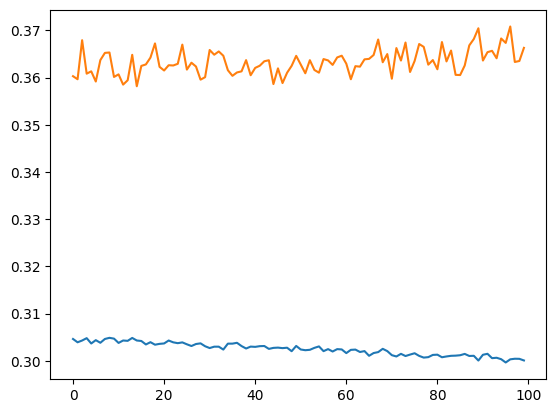

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])